# Timing Test: Direct vs Cascaded ST Pipelines

This notebook measures per-clip latency for the direct and cascaded speech-translation pipelines on the same 35 pilot clips. The purpose is feasibility testing for the eventual 4,200-sample run.

## 1. Purpose

This timing notebook is intentionally focused on computational feasibility, not translation quality. It measures per-clip runtime, records failures, and estimates the wall-clock cost of the full experiment.

In [1]:
from __future__ import annotations

import json
import platform
import sys
import time
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchaudio
from tqdm.auto import tqdm
from transformers import AutoModelForSeq2SeqLM, AutoProcessor, AutoTokenizer, SeamlessM4Tv2ForSpeechToText, pipeline


# PROJECT_ROOT is one directory above the notebook directory.
PROJECT_ROOT = Path.cwd().resolve()
print(f'Project root resolved to: {PROJECT_ROOT}')

CSV_PATH = PROJECT_ROOT / 'data' / 'timing_test_audio' / 'timing_test_35_clips.csv'
CLIP_DIR = PROJECT_ROOT / 'data' / 'timing_test_audio' / 'clips'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs' / 'timing'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if not CSV_PATH.exists():
    raise FileNotFoundError(
        'Could not find timing_test_35_clips.csv at project_root/data/timing_test_audio/. '
        f'Checked: {CSV_PATH}. '
        'Ensure this notebook is run from the notebooks directory.'
    )
if not CLIP_DIR.exists():
    raise FileNotFoundError(
        'Could not find clips directory at project_root/data/timing_test_audio/clips. '
        f'Checked: {CLIP_DIR}. '
        'Ensure this notebook is run from the notebooks directory.'
    )

# Fixed target language (no config lookup).
TARGET_LANGUAGE = 'zh'
MODEL_DIRECT = 'facebook/seamless-m4t-v2-large'
MODEL_ASR = 'openai/whisper-large-v2'
MODEL_MT = 'facebook/nllb-200-distilled-600M'

print(f'Project root resolved to: {PROJECT_ROOT}')
print(f'CSV path: {CSV_PATH}')
print(f'Clip directory: {CLIP_DIR}')
print(f'Target language: {TARGET_LANGUAGE}')
print(f'Direct model: {MODEL_DIRECT}')
print(f'ASR model: {MODEL_ASR}')
print(f'NLLB model: {MODEL_MT}')

Project root resolved to: /content
Project root resolved to: /content
CSV path: /content/data/timing_test_audio/timing_test_35_clips.csv
Clip directory: /content/data/timing_test_audio/clips
Target language: zh
Direct model: facebook/seamless-m4t-v2-large
ASR model: openai/whisper-large-v2
NLLB model: facebook/nllb-200-distilled-600M


## 2. Imports and Configuration

This section sets project paths, resolves the target language if a config exists, and prepares the libraries required for runtime logging and plotting.

In [2]:
def get_gpu_summary():
    if not torch.cuda.is_available():
        return {'name': None, 'total_memory_gb': None}
    try:
        props = torch.cuda.get_device_properties(torch.cuda.current_device())
        return {'name': props.name, 'total_memory_gb': round(float(props.total_memory / (1024 ** 3)), 2)}
    except Exception:
        return {'name': None, 'total_memory_gb': None}

gpu = get_gpu_summary()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
environment = {
    'timestamp_utc': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
    'python_version': sys.version.replace('\\n', ' '),
    'torch_version': torch.__version__,
    'transformers_version': __import__('transformers').__version__,
    'cuda_available': torch.cuda.is_available(),
    'cuda_version': torch.version.cuda if torch.cuda.is_available() else None,
    'gpu_name': gpu['name'],
    'gpu_memory_gb': gpu['total_memory_gb'],
    'device': str(device),
    'model_direct': MODEL_DIRECT,
    'model_asr': MODEL_ASR,
    'model_mt': MODEL_MT,
    'target_language': TARGET_LANGUAGE,
    'platform_system': platform.system(),
    'platform_release': platform.release(),
    'platform_version': platform.version(),
    'platform_machine': platform.machine(),
    'notebook_timing_methodology': 'time.perf_counter() with torch.cuda.synchronize() before and after each GPU inference call; model loading time is excluded from each clip measurement.',
}
for key, value in environment.items():
    print(f'{key}: {value}')

with (OUTPUTS_DIR / 'timing_test_environment.json').open('w', encoding='utf-8') as f:
    json.dump(environment, f, indent=2, sort_keys=True)


timestamp_utc: 2026-08-22T03:07:21Z
python_version: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
torch_version: 2.11.0+cu128
transformers_version: 5.15.0
cuda_available: True
cuda_version: 12.8
gpu_name: Tesla T4
gpu_memory_gb: 14.56
device: cuda
model_direct: facebook/seamless-m4t-v2-large
model_asr: openai/whisper-large-v2
model_mt: facebook/nllb-200-distilled-600M
target_language: zh
platform_system: Linux
platform_release: 6.6.122+
platform_version: #1 SMP Thu Apr 30 18:17:14 UTC 2026
platform_machine: x86_64
notebook_timing_methodology: time.perf_counter() with torch.cuda.synchronize() before and after each GPU inference call; model loading time is excluded from each clip measurement.


## 3. Hardware and Environment Information

Because runtime is hardware-dependent, the notebook records detailed environment metadata before the timing loop begins.

In [3]:
required_columns = [
    'client_id', 'path', 'sentence_id', 'sentence', 'sentence_domain', 'up_votes', 'down_votes',
    'age', 'gender', 'accents', 'variant', 'locale', 'segment', 'primary_accent',
    'sentence_norm', 'clip', 'duration[ms]', 'sentence_len_words', 'max_plausible_words',
    'sentence_len_chars'
]

df = pd.read_csv(CSV_PATH)
missing = [c for c in required_columns if c not in df.columns]
assert len(df) == 35, f'Expected exactly 35 rows, found {len(df)}'
assert not missing, f'Missing required columns: {missing}'

df['sample_id'] = df.apply(lambda r: f"{r['sentence_id']}_{r['client_id']}", axis=1)
seen = {}
for idx, row in df.iterrows():
    key = row['sample_id']
    if key in seen:
        seen[key] += 1
        df.at[idx, 'sample_id'] = f"{key}_{seen[key]}"
    else:
        seen[key] = 0

df['audio_path'] = df['clip'].map(lambda x: str(CLIP_DIR / str(x)))
audio_valid = df['audio_path'].map(lambda p: Path(p).exists())
missing_audio = df.loc[~audio_valid, ['sample_id', 'clip', 'audio_path']]
assert audio_valid.all(), f"Missing audio files: {missing_audio.to_dict('records')}"
assert df['sample_id'].is_unique, 'sample_id must be unique'
assert pd.to_numeric(df['duration[ms]'], errors='coerce').notna().all(), 'duration[ms] contains invalid values'
assert df['primary_accent'].notna().all(), 'primary_accent is missing in one or more rows'

print(f'Total rows: {len(df)}')
print(f'Valid audio files: {int(audio_valid.sum())}')
print(f'Missing audio files: {int((~audio_valid).sum())}')
print('Accent counts:')
print(df['primary_accent'].value_counts().to_string())
print(f"Mean audio duration (ms): {df['duration[ms]'].mean():.1f}")
print(f"Min audio duration (ms): {df['duration[ms]'].min():.1f}")
print(f"Max audio duration (ms): {df['duration[ms]'].max():.1f}")
print(f"Mean sentence length in words: {df['sentence_len_words'].mean():.2f}")
df['audio_duration_sec'] = df['duration[ms]'] / 1000.0
display(df[['sample_id', 'client_id', 'sentence_id', 'primary_accent', 'clip', 'audio_duration_sec', 'sentence_len_words']].head())


Total rows: 35
Valid audio files: 35
Missing audio files: 0
Accent counts:
primary_accent
England English                                       5
Filipino                                              5
Hong Kong English                                     5
India and South Asia (India, Pakistan, Sri Lanka)     5
Malaysian English                                     5
Southern African (South Africa, Zimbabwe, Namibia)    5
United States English                                 5
Mean audio duration (ms): 4651.2
Min audio duration (ms): 2232.0
Max audio duration (ms): 8424.0
Mean sentence length in words: 9.14


,sample_id,client_id,sentence_id,primary_accent,clip,audio_duration_sec,sentence_len_words
0,1f4e17468b0ae46e0bc22be117c073f7d85e54f15a3a0b...,d22f218cb2c44e73fdb321fef4dc52bc8995d28048330b...,1f4e17468b0ae46e0bc22be117c073f7d85e54f15a3a0b...,England English,common_voice_en_19695528.mp3,5.208,12
1,2c54888ad9e686725a29e6b7888e6b0cf27198d9a46c23...,48f48da505573df2ae0b591a7d6b7ace44cc94ac5838f6...,2c54888ad9e686725a29e6b7888e6b0cf27198d9a46c23...,England English,common_voice_en_20002436.mp3,3.792,7
2,0bd200f6b026ead6064433d4ea9a0cbbedd5d1a351f205...,46bb908b70bc8a4e4512ff78304e1f53aff78f86e34e2b...,0bd200f6b026ead6064433d4ea9a0cbbedd5d1a351f205...,England English,common_voice_en_685452.mp3,4.896,14
3,e4a0940769b7aa2773bd4ea62064ec73acb1e43a6afa1a...,fe4168562cc5f0320bc378cb946838be67dbe6808773ea...,e4a0940769b7aa2773bd4ea62064ec73acb1e43a6afa1a...,England English,common_voice_en_536327.mp3,8.424,10
4,01ac98c06562fbb5deb692ca12f66769dc6f799b4bbc47...,16ca33c77a4ff48f931fe63a9986938db81dc24e4be8eb...,01ac98c06562fbb5deb692ca12f66769dc6f799b4bbc47...,England English,common_voice_en_18711143.mp3,4.656,12


## 4. Load and Validate 35-Clip Timing Dataset

The CSV is validated before timing begins, including row count, required columns, valid audio paths, unique sample IDs, valid durations, and accent information.

## 5. Dataset Duration and Accent Summary

In [4]:
print('Mean audio duration (sec):', round(float(df['audio_duration_sec'].mean()), 3))
print('Median audio duration (sec):', round(float(df['audio_duration_sec'].median()), 3))
print('Total audio duration (sec):', round(float(df['audio_duration_sec'].sum()), 3))
print('Mean sentence length in words:', round(float(df['sentence_len_words'].mean()), 2))

Mean audio duration (sec): 4.651
Median audio duration (sec): 4.296
Total audio duration (sec): 162.792
Mean sentence length in words: 9.14


## 6. Timing Methodology

Each clip is measured individually with `time.perf_counter()`. If CUDA is in use, we call `torch.cuda.synchronize()` immediately before and after the inference call to account for asynchronous GPU execution.

In [5]:
def sync_if_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def timed_inference(fn, *args, **kwargs):
    sync_if_cuda()
    t0 = time.perf_counter()
    with torch.inference_mode():
        result = fn(*args, **kwargs)
    sync_if_cuda()
    elapsed = time.perf_counter() - t0
    return result, elapsed

## 7. Load Models

In [6]:
try:
    direct_processor = AutoProcessor.from_pretrained(MODEL_DIRECT)
    direct_model = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_DIRECT)
    direct_model.to(device)
    direct_model.eval()

    asr_pipe = pipeline(
        'automatic-speech-recognition',
        model=MODEL_ASR,
        device=0 if torch.cuda.is_available() else -1,
        model_kwargs={'torch_dtype': torch.float16 if torch.cuda.is_available() else torch.float32},
    )

    nllb_tokenizer = AutoTokenizer.from_pretrained(MODEL_MT, src_lang='eng_Latn')
    nllb_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_MT)
    nllb_model.to(device)
    nllb_model.eval()
    print('All required models loaded.')
except Exception as exc:
    print(f'Model loading failed: {exc}')
    direct_processor = None
    direct_model = None
    asr_pipe = None
    nllb_tokenizer = None
    nllb_model = None

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


preprocessor_config.json:   0%|          | 0.00/1.78k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.72k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/19.7k [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B / 5.17MB            

...

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.46GB            

model.safetensors: downloading bytes:           |  0.00B            

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

All required models loaded.


## 8. Warm-Up

In [7]:
SEAMLESS_SAMPLE_RATE = 16000

def load_waveform(audio_path, target_sr: int = SEAMLESS_SAMPLE_RATE):
    waveform, sr = torchaudio.load(audio_path)
    # Convert multi-channel audio to mono to keep processor input consistent.
    if waveform.ndim == 2 and waveform.size(0) > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    # Resample to the rate required by SeamlessM4T feature extractor.
    if sr != target_sr:
        waveform = torchaudio.functional.resample(waveform, sr, target_sr)
        sr = target_sr
    waveform = waveform.squeeze(0).contiguous()
    return waveform, sr

def direct_translate_single(audio_path: str, processor, model, target_lang: str):
    waveform, sr = load_waveform(audio_path)
    inputs = processor(audio=waveform.numpy(), sampling_rate=sr, return_tensors='pt')
    input_features = inputs['input_features'].to(device)
    attention_mask = inputs.get('attention_mask')
    if attention_mask is not None:
        attention_mask = attention_mask.to(device)
    seamless_target_lang = 'cmn' if target_lang == 'zh' else target_lang
    generated = model.generate(
        input_features,
        attention_mask=attention_mask,
        tgt_lang=seamless_target_lang,
    )
    return processor.batch_decode(generated, skip_special_tokens=True)[0]

def asr_single(audio_path: str):
    if asr_pipe is None:
        raise RuntimeError('ASR pipeline not loaded')
    result = asr_pipe(audio_path, return_timestamps=False, max_new_tokens=128)
    if isinstance(result, dict):
        return result.get('text', '')
    if isinstance(result, list):
        return result[0].get('text', '') if result else ''
    return str(result)

def nllb_translate_single(text: str, tokenizer, model, target_lang_code: str):
    if tokenizer is None or model is None:
        raise RuntimeError('NLLB model or tokenizer not available')
    inputs = tokenizer(text, return_tensors='pt', truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    nllb_target_lang = {'zh': 'zho_Hans'}.get(target_lang_code, target_lang_code)
    target_token = tokenizer.convert_tokens_to_ids(nllb_target_lang)
    if target_token is None or target_token == tokenizer.unk_token_id:
        raise ValueError(f'Unsupported NLLB target language code: {nllb_target_lang!r}')
    generated = model.generate(**inputs, forced_bos_token_id=target_token)
    return tokenizer.decode(generated[0], skip_special_tokens=True)

warmup_path = df.iloc[0]['audio_path']
if direct_model is not None and direct_processor is not None:
    _, _ = timed_inference(direct_translate_single, warmup_path, direct_processor, direct_model, TARGET_LANGUAGE)
    print('Direct warm-up complete')
if asr_pipe is not None and nllb_model is not None and nllb_tokenizer is not None:
    asr_text, _ = timed_inference(asr_single, warmup_path)
    _, _ = timed_inference(nllb_translate_single, asr_text, nllb_tokenizer, nllb_model, TARGET_LANGUAGE)
    print('Cascade warm-up complete')

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer SeamlessM4TTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Direct warm-up complete


[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugg

Cascade warm-up complete


## 9. Direct Pipeline Timing

In [8]:
direct_rows = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc='Direct pipeline'):
    rec = {
        'sample_id': row['sample_id'],
        'client_id': row['client_id'],
        'sentence_id': row['sentence_id'],
        'primary_accent': row['primary_accent'],
        'clip': row['clip'],
        'audio_path': row['audio_path'],
        'duration_ms': row['duration[ms]'],
        'audio_duration_sec': row['audio_duration_sec'],
        'sentence_len_words': row['sentence_len_words'],
        'sentence_len_chars': row['sentence_len_chars'],
        'direct_translation': None,
        'direct_runtime_sec': None,
        'direct_realtime_factor': None,
        'direct_status': 'failed',
        'direct_error': None,
    }
    try:
        if direct_model is None or direct_processor is None:
            raise RuntimeError('Direct model not loaded')
        translation, runtime = timed_inference(direct_translate_single, row['audio_path'], direct_processor, direct_model, TARGET_LANGUAGE)
        rec['direct_translation'] = translation
        rec['direct_runtime_sec'] = float(runtime)
        rec['direct_realtime_factor'] = float(runtime) / float(row['audio_duration_sec']) if row['audio_duration_sec'] > 0 else None
        rec['direct_status'] = 'success'
        print(f"[Direct] {idx + 1:02d}/{len(df)} | accent={row['primary_accent']} | audio={row['audio_duration_sec']:.2f}s | runtime={runtime:.4f}s | RTF={rec['direct_realtime_factor']:.2f}")
    except Exception as exc:
        rec['direct_error'] = repr(exc)
        print(f"[Direct] {idx + 1:02d}/{len(df)} FAILED | accent={row['primary_accent']} | error={exc}")
    direct_rows.append(rec)

direct_df = pd.DataFrame(direct_rows)
display(direct_df.head())

Direct pipeline:   0%|          | 0/35 [00:00<?, ?it/s]

[Direct] 01/35 | accent=England English | audio=5.21s | runtime=1.0917s | RTF=0.21
[Direct] 02/35 | accent=England English | audio=3.79s | runtime=3.3033s | RTF=0.87
[Direct] 03/35 | accent=England English | audio=4.90s | runtime=5.7536s | RTF=1.18
[Direct] 04/35 | accent=England English | audio=8.42s | runtime=6.1054s | RTF=0.72
[Direct] 05/35 | accent=England English | audio=4.66s | runtime=1.9539s | RTF=0.42
[Direct] 06/35 | accent=Filipino | audio=5.52s | runtime=3.6835s | RTF=0.67
[Direct] 07/35 | accent=Filipino | audio=7.46s | runtime=1.1398s | RTF=0.15
[Direct] 08/35 | accent=Filipino | audio=6.79s | runtime=4.6429s | RTF=0.68
[Direct] 09/35 | accent=Filipino | audio=6.12s | runtime=0.9494s | RTF=0.16
[Direct] 10/35 | accent=Filipino | audio=3.12s | runtime=5.7475s | RTF=1.84
[Direct] 11/35 | accent=Hong Kong English | audio=3.34s | runtime=1.0474s | RTF=0.31
[Direct] 12/35 | accent=Hong Kong English | audio=4.30s | runtime=0.9042s | RTF=0.21
[Direct] 13/35 | accent=Hong Kong E

,sample_id,client_id,sentence_id,primary_accent,clip,audio_path,duration_ms,audio_duration_sec,sentence_len_words,sentence_len_chars,direct_translation,direct_runtime_sec,direct_realtime_factor,direct_status,direct_error
0,1f4e17468b0ae46e0bc22be117c073f7d85e54f15a3a0b...,d22f218cb2c44e73fdb321fef4dc52bc8995d28048330b...,1f4e17468b0ae46e0bc22be117c073f7d85e54f15a3a0b...,England English,common_voice_en_19695528.mp3,/content/data/timing_test_audio/clips/common_v...,5208,5.208,12,63,"事实上,街道编号系统是基于网格计划的.",1.091704,0.209621,success,None
1,2c54888ad9e686725a29e6b7888e6b0cf27198d9a46c23...,48f48da505573df2ae0b591a7d6b7ace44cc94ac5838f6...,2c54888ad9e686725a29e6b7888e6b0cf27198d9a46c23...,England English,common_voice_en_20002436.mp3,/content/data/timing_test_audio/clips/common_v...,3792,3.792,7,36,船员们再也没有说他的名字了.,3.303330,0.871131,success,None
2,0bd200f6b026ead6064433d4ea9a0cbbedd5d1a351f205...,46bb908b70bc8a4e4512ff78304e1f53aff78f86e34e2b...,0bd200f6b026ead6064433d4ea9a0cbbedd5d1a351f205...,England English,common_voice_en_685452.mp3,/content/data/timing_test_audio/clips/common_v...,4896,4.896,14,72,"这些人爬上了山,到达山顶时他们已经疲<unk>不堪.",5.753648,1.175173,success,None
3,e4a0940769b7aa2773bd4ea62064ec73acb1e43a6afa1a...,fe4168562cc5f0320bc378cb946838be67dbe6808773ea...,e4a0940769b7aa2773bd4ea62064ec73acb1e43a6afa1a...,England English,common_voice_en_536327.mp3,/content/data/timing_test_audio/clips/common_v...,8424,8.424,10,50,那天晚上似乎没有人想到这一点.,6.105438,0.724767,success,None
4,01ac98c06562fbb5deb692ca12f66769dc6f799b4bbc47...,16ca33c77a4ff48f931fe63a9986938db81dc24e4be8eb...,01ac98c06562fbb5deb692ca12f66769dc6f799b4bbc47...,England English,common_voice_en_18711143.mp3,/content/data/timing_test_audio/clips/common_v...,4656,4.656,12,61,这首歌由乡村音乐艺术家克里斯·莱杜克斯 (Chris LeDoux) 创作.,1.953854,0.419642,success,None


## 10. Cascaded Pipeline Timing

In [9]:
cascade_rows = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc='Cascade pipeline'):
    rec = {
        'sample_id': row['sample_id'],
        'client_id': row['client_id'],
        'sentence_id': row['sentence_id'],
        'primary_accent': row['primary_accent'],
        'clip': row['clip'],
        'audio_path': row['audio_path'],
        'duration_ms': row['duration[ms]'],
        'audio_duration_sec': row['audio_duration_sec'],
        'sentence_len_words': row['sentence_len_words'],
        'sentence_len_chars': row['sentence_len_chars'],
        'asr_transcript': None,
        'whisper_runtime_sec': None,
        'cascaded_translation': None,
        'nllb_runtime_sec': None,
        'cascade_runtime_sec': None,
        'cascade_end_to_end_runtime_sec': None,
        'cascade_realtime_factor': None,
        'cascade_status': 'failed',
        'cascade_error': None,
    }
    try:
        if asr_pipe is None or nllb_model is None or nllb_tokenizer is None:
            raise RuntimeError('Cascade models not loaded')
        asr_text, whisper_runtime = timed_inference(asr_single, row['audio_path'])
        rec['asr_transcript'] = asr_text
        rec['whisper_runtime_sec'] = float(whisper_runtime)
        nllb_text, nllb_runtime = timed_inference(nllb_translate_single, asr_text, nllb_tokenizer, nllb_model, TARGET_LANGUAGE)
        rec['cascaded_translation'] = nllb_text
        rec['nllb_runtime_sec'] = float(nllb_runtime)
        rec['cascade_runtime_sec'] = float(rec['whisper_runtime_sec']) + float(rec['nllb_runtime_sec'])
        rec['cascade_end_to_end_runtime_sec'] = rec['cascade_runtime_sec']
        rec['cascade_realtime_factor'] = float(rec['cascade_runtime_sec']) / float(row['audio_duration_sec']) if row['audio_duration_sec'] > 0 else None
        rec['cascade_status'] = 'success'
        print(f"[Cascade] {idx + 1:02d}/{len(df)} | accent={row['primary_accent']} | audio={row['audio_duration_sec']:.2f}s | Whisper={rec['whisper_runtime_sec']:.4f}s | NLLB={rec['nllb_runtime_sec']:.4f}s | total={rec['cascade_runtime_sec']:.4f}s | RTF={rec['cascade_realtime_factor']:.2f}")
    except Exception as exc:
        rec['cascade_error'] = repr(exc)
        print(f"[Cascade] {idx + 1:02d}/{len(df)} FAILED | accent={row['primary_accent']} | error={exc}")
    cascade_rows.append(rec)

cascade_df = pd.DataFrame(cascade_rows)
display(cascade_df.head())

Cascade pipeline:   0%|          | 0/35 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[Cascade] 01/35 | accent=England English | audio=5.21s | Whisper=1.7817s | NLLB=0.2549s | total=2.0366s | RTF=0.39


[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[Cascade] 02/35 | accent=England English | audio=3.79s | Whisper=1.0639s | NLLB=0.2037s | total=1.2676s | RTF=0.33


...

[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[Cascade] 34/35 | accent=United States English | audio=3.82s | Whisper=1.3130s | NLLB=0.2112s | total=1.5241s | RTF=0.40


[transformers] Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[Cascade] 35/35 | accent=United States English | audio=3.74s | Whisper=1.1692s | NLLB=0.1453s | total=1.3146s | RTF=0.35


,sample_id,client_id,sentence_id,primary_accent,clip,audio_path,duration_ms,audio_duration_sec,sentence_len_words,sentence_len_chars,asr_transcript,whisper_runtime_sec,cascaded_translation,nllb_runtime_sec,cascade_runtime_sec,cascade_end_to_end_runtime_sec,cascade_realtime_factor,cascade_status,cascade_error
0,1f4e17468b0ae46e0bc22be117c073f7d85e54f15a3a0b...,d22f218cb2c44e73fdb321fef4dc52bc8995d28048330b...,1f4e17468b0ae46e0bc22be117c073f7d85e54f15a3a0b...,England English,common_voice_en_19695528.mp3,/content/data/timing_test_audio/clips/common_v...,5208,5.208,12,63,"In fact, the street numbering system is based...",1.781674,"实际上,街道编号系统是基于网格计划的.",0.254946,2.036620,2.036620,0.391056,success,None
1,2c54888ad9e686725a29e6b7888e6b0cf27198d9a46c23...,48f48da505573df2ae0b591a7d6b7ace44cc94ac5838f6...,2c54888ad9e686725a29e6b7888e6b0cf27198d9a46c23...,England English,common_voice_en_20002436.mp3,/content/data/timing_test_audio/clips/common_v...,3792,3.792,7,36,The crew never speak his name again.,1.063913,团队从来没有说过他的名字.,0.203693,1.267606,1.267606,0.334284,success,None
2,0bd200f6b026ead6064433d4ea9a0cbbedd5d1a351f205...,46bb908b70bc8a4e4512ff78304e1f53aff78f86e34e2b...,0bd200f6b026ead6064433d4ea9a0cbbedd5d1a351f205...,England English,common_voice_en_685452.mp3,/content/data/timing_test_audio/clips/common_v...,4896,4.896,14,72,The men climbed the hill and they were tired ...,1.330029,"那些人爬上山,到顶峰时,他们很累.",0.268650,1.598680,1.598680,0.326528,success,None
3,e4a0940769b7aa2773bd4ea62064ec73acb1e43a6afa1a...,fe4168562cc5f0320bc378cb946838be67dbe6808773ea...,e4a0940769b7aa2773bd4ea62064ec73acb1e43a6afa1a...,England English,common_voice_en_536327.mp3,/content/data/timing_test_audio/clips/common_v...,8424,8.424,10,50,No one seemed to have thought about it that n...,1.152187,那天晚上似乎没有人想过.,0.175728,1.327914,1.327914,0.157635,success,None
4,01ac98c06562fbb5deb692ca12f66769dc6f799b4bbc47...,16ca33c77a4ff48f931fe63a9986938db81dc24e4be8eb...,01ac98c06562fbb5deb692ca12f66769dc6f799b4bbc47...,England English,common_voice_en_18711143.mp3,/content/data/timing_test_audio/clips/common_v...,4656,4.656,12,61,A song by the same name by country music arti...,1.338494,乡村音乐艺术家克里斯·莱多克斯的同名歌曲.,0.443347,1.781841,1.781841,0.382698,success,None


## 11. Combine and Save Timing Results

In [10]:
df = df.merge(direct_df[['sample_id', 'direct_translation', 'direct_runtime_sec', 'direct_realtime_factor', 'direct_status', 'direct_error']], on='sample_id', how='left')
df = df.merge(cascade_df[['sample_id', 'asr_transcript', 'whisper_runtime_sec', 'cascaded_translation', 'nllb_runtime_sec', 'cascade_runtime_sec', 'cascade_end_to_end_runtime_sec', 'cascade_realtime_factor', 'cascade_status', 'cascade_error']], on='sample_id', how='left')
df['preferred_cascade_runtime_sec'] = df['cascade_end_to_end_runtime_sec'].fillna(df['cascade_runtime_sec'])
df['runtime_difference_sec'] = df['preferred_cascade_runtime_sec'] - df['direct_runtime_sec']

result_path = OUTPUTS_DIR / 'timing_test_35_clips_results.csv'
df.to_csv(result_path, index=False)
try:
    df.to_parquet(OUTPUTS_DIR / 'timing_test_35_clips_results.parquet', index=False)
except Exception as exc:
    print(f'Parquet export skipped: {exc}')
print(f'Results saved to {result_path}')
display(df.head())

Results saved to /content/outputs/timing/timing_test_35_clips_results.csv


,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,...,whisper_runtime_sec,cascaded_translation,nllb_runtime_sec,cascade_runtime_sec,cascade_end_to_end_runtime_sec,cascade_realtime_factor,cascade_status,cascade_error,preferred_cascade_runtime_sec,runtime_difference_sec
0,d22f218cb2c44e73fdb321fef4dc52bc8995d28048330b...,common_voice_en_19695528.mp3,1f4e17468b0ae46e0bc22be117c073f7d85e54f15a3a0b...,"In fact, the street numbering system is based ...",NaN,2,0,thirties,male_masculine,England English,...,1.781674,"实际上,街道编号系统是基于网格计划的.",0.254946,2.036620,2.036620,0.391056,success,None,2.036620,0.944916
1,48f48da505573df2ae0b591a7d6b7ace44cc94ac5838f6...,common_voice_en_20002436.mp3,2c54888ad9e686725a29e6b7888e6b0cf27198d9a46c23...,The crew never speak his name again.,NaN,2,0,twenties,female_feminine,England English,...,1.063913,团队从来没有说过他的名字.,0.203693,1.267606,1.267606,0.334284,success,None,1.267606,-2.035724
2,46bb908b70bc8a4e4512ff78304e1f53aff78f86e34e2b...,common_voice_en_685452.mp3,0bd200f6b026ead6064433d4ea9a0cbbedd5d1a351f205...,"The men climbed the hill, and they were tired ...",NaN,2,0,twenties,male_masculine,England English,...,1.330029,"那些人爬上山,到顶峰时,他们很累.",0.268650,1.598680,1.598680,0.326528,success,None,1.598680,-4.154968
3,fe4168562cc5f0320bc378cb946838be67dbe6808773ea...,common_voice_en_536327.mp3,e4a0940769b7aa2773bd4ea62064ec73acb1e43a6afa1a...,No one seemed to have thought about it that ni...,NaN,2,0,fourties,female_feminine,England English,...,1.152187,那天晚上似乎没有人想过.,0.175728,1.327914,1.327914,0.157635,success,None,1.327914,-4.777524
4,16ca33c77a4ff48f931fe63a9986938db81dc24e4be8eb...,common_voice_en_18711143.mp3,01ac98c06562fbb5deb692ca12f66769dc6f799b4bbc47...,A song by the same name by country music artis...,NaN,4,2,teens,male_masculine,England English|Northern England,...,1.338494,乡村音乐艺术家克里斯·莱多克斯的同名歌曲.,0.443347,1.781841,1.781841,0.382698,success,None,1.781841,-0.172014


In [11]:
sample_results_table = df[[
    'sentence',
    'accents',
    'direct_translation',
    'cascaded_translation',
    'preferred_cascade_runtime_sec',
    'direct_runtime_sec',
]].copy()

sample_results_table[['preferred_cascade_runtime_sec', 'direct_runtime_sec']] = (
    sample_results_table[['preferred_cascade_runtime_sec', 'direct_runtime_sec']].round(4)
)
sample_results_table = sample_results_table.rename(columns={
    'cascaded_translation': 'cascade_translation',
    'preferred_cascade_runtime_sec': 'cascade_runtime',
    'direct_runtime_sec': 'direct_runtime',
})

with pd.option_context('display.max_rows', 35, 'display.max_colwidth', 200):
    display(sample_results_table)

,sentence,accents,direct_translation,cascade_translation,cascade_runtime,direct_runtime
0,"In fact, the street numbering system is based on the Grid plan.",England English,"事实上,街道编号系统是基于网格计划的.","实际上,街道编号系统是基于网格计划的.",2.0366,1.0917
1,The crew never speak his name again.,England English,船员们再也没有说他的名字了.,团队从来没有说过他的名字.,1.2676,3.3033
2,"The men climbed the hill, and they were tired when they reached the top.",England English,"这些人爬上了山,到达山顶时他们已经疲<unk>不堪.","那些人爬上山,到顶峰时,他们很累.",1.5987,5.7536
3,No one seemed to have thought about it that night.,England English,那天晚上似乎没有人想到这一点.,那天晚上似乎没有人想过.,1.3279,6.1054
4,A song by the same name by country music artist Chris LeDoux.,England English|Northern England,这首歌由乡村音乐艺术家克里斯·莱杜克斯 (Chris LeDoux) 创作.,乡村音乐艺术家克里斯·莱多克斯的同名歌曲.,1.7818,1.9539
5,"Sorry, I'll explain more when I actually understand what's going on.",Filipino,"很抱歉,当我真正理解发生了什么事时,我会解释更多.","我会解释更多,当我真正明白发生了什么.",1.8922,3.6835
6,The course of the battle is differently related in the contemporaneous historical records.,Filipino,战役的过程在当代历史记录中有所不同.,"现代历史记录中,战斗的进程是不同的.",1.6169,1.1398
7,The seventeen-year-old girl gently pushed his hand away as he touched her belly.,Filipino,"十七岁的女孩轻轻地推开他的手,因为他触摸她的肚子.","这位17岁的女孩轻轻地把他的手推开,",1.7401,4.6429
8,"Without knowing where they went, there's not much we can do but wait.",Filipino,"没有知道他们去哪里,我们只能等待.","没有知道他们去哪里,我们只能等待.",1.6670,0.9494
9,YOU WANNA TAKE THIS OUTSIDE?,Filipino,你想把这个带出去吗?,你想出去看看吗?,1.0889,5.7475


## 12. Runtime Summary Statistics

In [12]:
def summarize(values):
    s = pd.Series(values).dropna()
    if s.empty:
        return {'successful': 0, 'failed': 0, 'mean': np.nan, 'median': np.nan, 'min': np.nan, 'max': np.nan, 'std': np.nan, 'total': np.nan}
    return {'successful': int(len(s)), 'failed': int(len(df) - len(s)), 'mean': float(s.mean()), 'median': float(s.median()), 'min': float(s.min()), 'max': float(s.max()), 'std': float(s.std(ddof=1)) if len(s) > 1 else 0.0, 'total': float(s.sum())}

direct_runtime_values = df['direct_runtime_sec'].dropna()
cascade_runtime_values = df['preferred_cascade_runtime_sec'].dropna()
direct_rtf_values = df['direct_realtime_factor'].dropna()
cascade_rtf_values = df['cascade_realtime_factor'].dropna()
whisper_runtime_values = df['whisper_runtime_sec'].dropna()
nllb_runtime_values = df['nllb_runtime_sec'].dropna()

print('Direct summary:', summarize(direct_runtime_values))
print('Cascade summary:', summarize(cascade_runtime_values))
print('Mean Whisper runtime:', whisper_runtime_values.mean())
print('Median Whisper runtime:', whisper_runtime_values.median())
print('Mean NLLB runtime:', nllb_runtime_values.mean())
print('Median NLLB runtime:', nllb_runtime_values.median())
print('Mean Direct RTF:', direct_rtf_values.mean())
print('Median Direct RTF:', direct_rtf_values.median())
print('Mean Cascade RTF:', cascade_rtf_values.mean())
print('Median Cascade RTF:', cascade_rtf_values.median())
print('Whisper percentage of Cascade runtime:', whisper_runtime_values.mean() / cascade_runtime_values.mean())
print('NLLB percentage of Cascade runtime:', nllb_runtime_values.mean() / cascade_runtime_values.mean())
print('Mean audio duration (sec):', df['audio_duration_sec'].mean())
print('Median audio duration (sec):', df['audio_duration_sec'].median())
print('Mean sentence length in words:', df['sentence_len_words'].mean())

Direct summary: {'successful': 35, 'failed': 0, 'mean': 1.665430926914275, 'median': 0.9284829869999385, 'min': 0.6480948119999539, 'max': 6.105438217000028, 'std': 1.5769888221916437, 'total': 58.29008244199963}
Cascade summary: {'successful': 35, 'failed': 0, 'mean': 1.4679059928571372, 'median': 1.4144314030000942, 'min': 0.9687648860000309, 'max': 2.434260543999926, 'std': 0.33413615492831655, 'total': 51.376709749999804}
Mean Whisper runtime: 1.2489782743999966
Median Whisper runtime: 1.2013197490000493
Mean NLLB runtime: 0.21892771845714054
Median NLLB runtime: 0.21425807900004656
Mean Direct RTF: 0.36580058977704466
Median Direct RTF: 0.2560335900537569
Mean Cascade RTF: 0.34145000404436426
Median Cascade RTF: 0.3427829480072398
Whisper percentage of Cascade runtime: 0.8508571260540881
NLLB percentage of Cascade runtime: 0.1491428739459118
Mean audio duration (sec): 4.651200000000001
Median audio duration (sec): 4.296
Mean sentence length in words: 9.142857142857142


## 13. Full 4,200-Sample Runtime Estimate

In [ ]:
N_TOTAL = 4200
estimated_direct_mean = direct_runtime_values.mean() * N_TOTAL
estimated_direct_median = direct_runtime_values.median() * N_TOTAL
estimated_cascade_mean = cascade_runtime_values.mean() * N_TOTAL
estimated_cascade_median = cascade_runtime_values.median() * N_TOTAL
estimated_combined_mean = estimated_direct_mean + estimated_cascade_mean
estimated_combined_median = estimated_direct_median + estimated_cascade_median
print(f'Estimated Direct runtime for 4,200 clips (mean): {estimated_direct_mean / 3600:.2f} hours')
print(f'Estimated Direct runtime for 4,200 clips (median): {estimated_direct_median / 3600:.2f} hours')
print(f'Estimated Cascade runtime for 4,200 clips (mean): {estimated_cascade_mean / 3600:.2f} hours')
print(f'Estimated Cascade runtime for 4,200 clips (median): {estimated_cascade_median / 3600:.2f} hours')
print(f'Estimated combined runtime (mean): {estimated_combined_mean / 3600:.2f} hours')
print(f'Estimated combined runtime (median): {estimated_combined_median / 3600:.2f} hours')
print('This is a linear estimate and actual runtime can vary because of audio-duration distribution, GPU hardware, thermal throttling, caching, model/device configuration, failed samples, batching, multiprocessing, or system load.')

Estimated Direct runtime for 4,200 clips (mean): 1.94 hours
Estimated Direct runtime for 4,200 clips (median): 1.08 hours
Estimated Cascade runtime for 4,200 clips (mean): 1.71 hours
Estimated Cascade runtime for 4,200 clips (median): 1.65 hours
Estimated combined runtime (mean): 3.66 hours
Estimated combined runtime (median): 2.73 hours
This is a linear estimate and actual runtime can vary because of audio-duration distribution, GPU hardware, thermal throttling, caching, model/device configuration, failed samples, batching, multiprocessing, or system load.


## 14. Runtime Visualisations

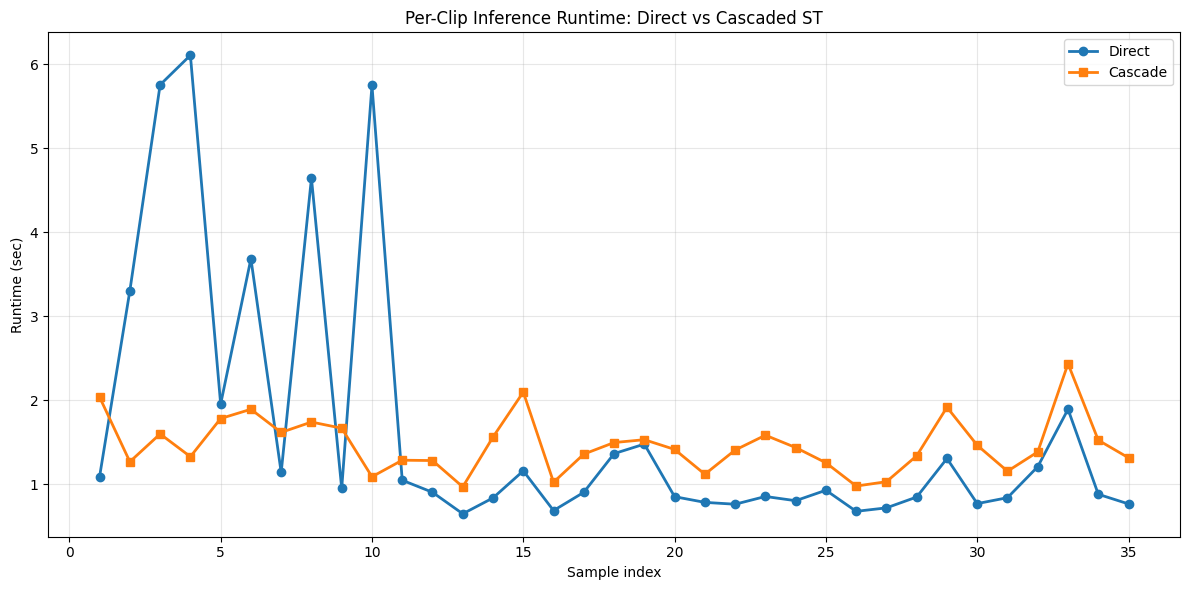

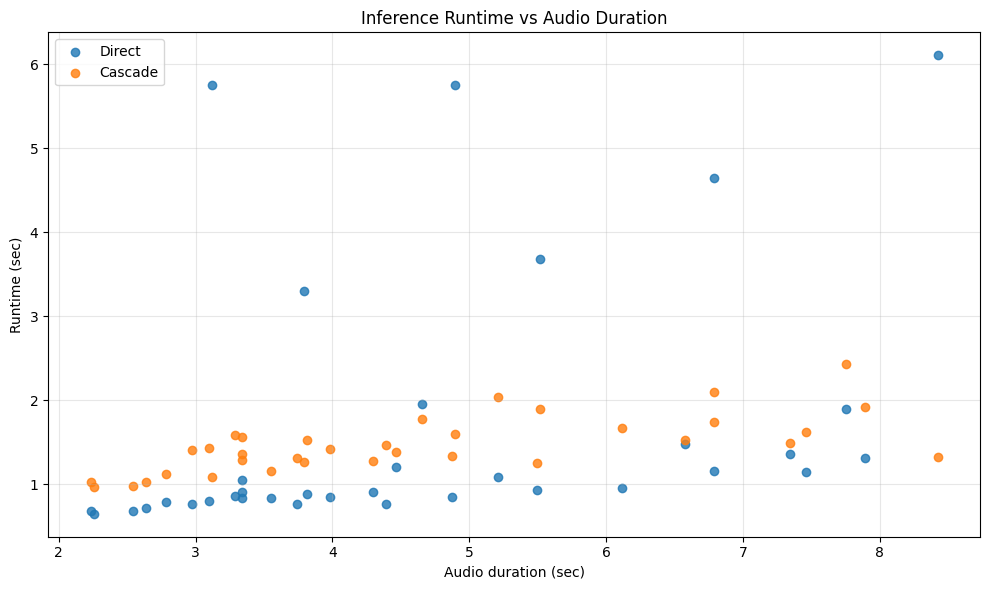

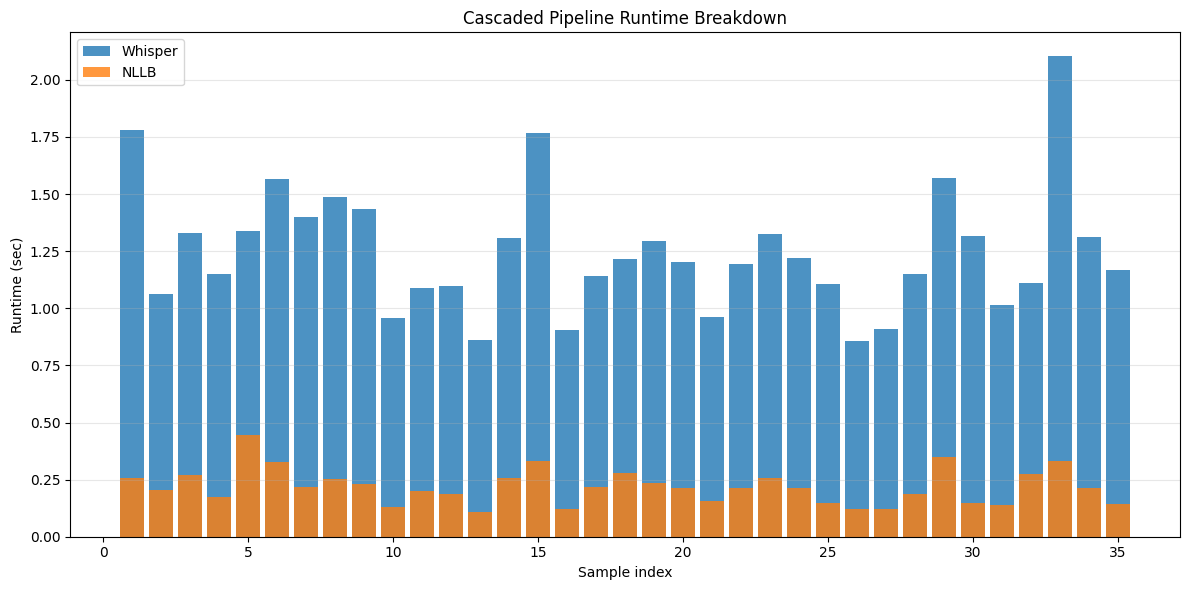

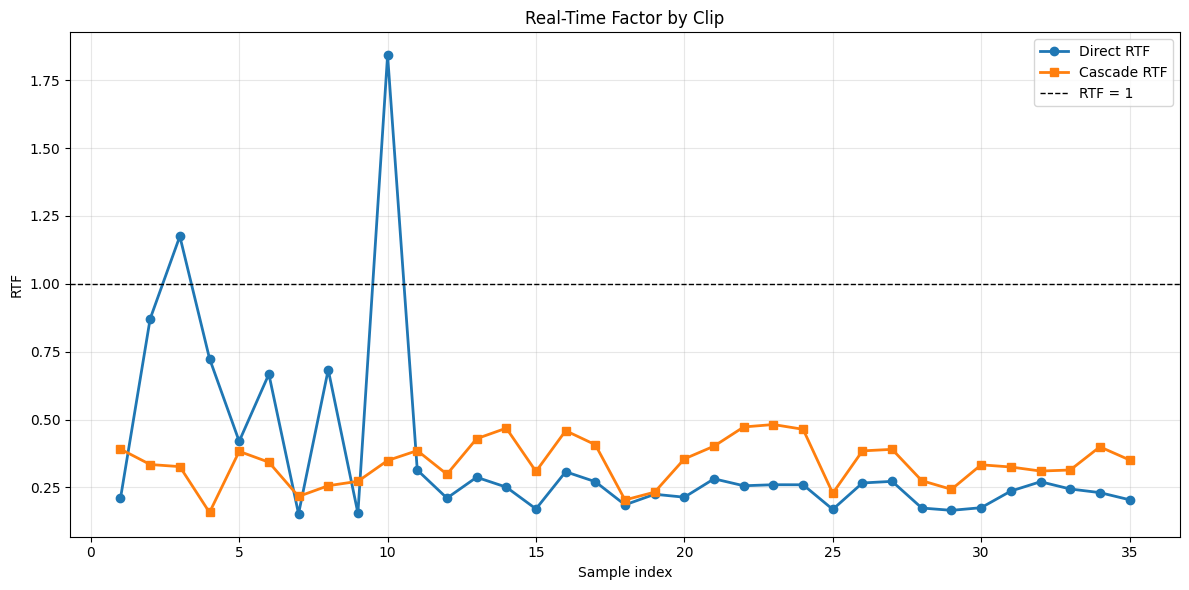

Saved figures to /content/results/figures


In [14]:
sample_idx = np.arange(1, len(df) + 1)

plt.figure(figsize=(12, 6))
plt.plot(sample_idx, df['direct_runtime_sec'].fillna(0), marker='o', linewidth=2, label='Direct')
plt.plot(sample_idx, df['preferred_cascade_runtime_sec'].fillna(0), marker='s', linewidth=2, label='Cascade')
plt.title('Per-Clip Inference Runtime: Direct vs Cascaded ST')
plt.xlabel('Sample index')
plt.ylabel('Runtime (sec)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'timing_direct_vs_cascade_35_clips.png', dpi=200)

plt.figure(figsize=(10, 6))
plt.scatter(df['audio_duration_sec'], df['direct_runtime_sec'], label='Direct', alpha=0.8)
plt.scatter(df['audio_duration_sec'], df['preferred_cascade_runtime_sec'], label='Cascade', alpha=0.8)
plt.title('Inference Runtime vs Audio Duration')
plt.xlabel('Audio duration (sec)')
plt.ylabel('Runtime (sec)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'timing_vs_audio_duration.png', dpi=200)

plt.figure(figsize=(12, 6))
plt.bar(sample_idx, df['whisper_runtime_sec'].fillna(0), label='Whisper', alpha=0.8)
plt.bar(sample_idx, df['nllb_runtime_sec'].fillna(0), label='NLLB', alpha=0.8)
plt.title('Cascaded Pipeline Runtime Breakdown')
plt.xlabel('Sample index')
plt.ylabel('Runtime (sec)')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cascade_runtime_breakdown.png', dpi=200)

plt.figure(figsize=(12, 6))
plt.plot(sample_idx, df['direct_realtime_factor'].fillna(0), marker='o', linewidth=2, label='Direct RTF')
plt.plot(sample_idx, df['cascade_realtime_factor'].fillna(0), marker='s', linewidth=2, label='Cascade RTF')
plt.axhline(1.0, color='black', linestyle='--', linewidth=1, label='RTF = 1')
plt.title('Real-Time Factor by Clip')
plt.xlabel('Sample index')
plt.ylabel('RTF')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'realtime_factor_35_clips.png', dpi=200)
plt.show()
print(f'Saved figures to {FIGURES_DIR}')

In [15]:
print('Summary of inference runtimes and real-time factors:')

Summary of inference runtimes and real-time factors:


## 15. Feasibility Conclusion

In [16]:
print(f"1. Mean and median Direct ST per-clip runtime: {direct_runtime_values.mean():.4f}s and {direct_runtime_values.median():.4f}s")
print(f"2. Mean and median Cascaded ST per-clip runtime: {cascade_runtime_values.mean():.4f}s and {cascade_runtime_values.median():.4f}s")
print(f"3. Runtime variation across 35 clips: Direct std={direct_runtime_values.std(ddof=1):.4f}s; Cascade std={cascade_runtime_values.std(ddof=1):.4f}s")
print(f"4. Runtime relationship with audio duration: Direct corr={df['audio_duration_sec'].corr(df['direct_runtime_sec']):.3f}; Cascade corr={df['audio_duration_sec'].corr(df['preferred_cascade_runtime_sec']):.3f}")
print(f"5. Average Direct real-time factor: {direct_rtf_values.mean():.3f}")
print(f"6. Average Cascade real-time factor: {cascade_rtf_values.mean():.3f}")
print(f"7. Whisper vs NLLB timing: Whisper mean={whisper_runtime_values.mean():.3f}s; NLLB mean={nllb_runtime_values.mean():.3f}s")
print(f"8. Estimated Direct runtime for 4,200 clips: {estimated_direct_mean / 3600:.2f} hours")
print(f"9. Estimated Cascade runtime for 4,200 clips: {estimated_cascade_mean / 3600:.2f} hours")
print(f"10. Estimated combined runtime: {estimated_combined_mean / 3600:.2f} hours")

if estimated_combined_mean / 3600 <= 12:
    feasibility = 'Based on the current hardware, the full 4,200-sample experimental run appears computationally feasible within a practical wall-clock budget.'
else:
    feasibility = 'Based on the current hardware, the full 4,200-sample experiment is likely expensive and may require staged execution or more efficient scheduling.'
print(f"11. Feasibility conclusion: {feasibility}")
print('')
print('Final feasibility statement: ' + feasibility)

summary_table = pd.DataFrame({
    'Pipeline': ['Direct', 'Cascade'],
    'Mean sec/clip': [direct_runtime_values.mean(), cascade_runtime_values.mean()],
    'Median': [direct_runtime_values.median(), cascade_runtime_values.median()],
    'Min': [direct_runtime_values.min(), cascade_runtime_values.min()],
    'Max': [direct_runtime_values.max(), cascade_runtime_values.max()],
    'Mean RTF': [direct_rtf_values.mean(), cascade_rtf_values.mean()],
    'Total 35 clips': [direct_runtime_values.sum(), cascade_runtime_values.sum()],
    'Estimated 4200 hours': [estimated_direct_mean / 3600, estimated_cascade_mean / 3600],
})
display(summary_table)

1. Mean and median Direct ST per-clip runtime: 1.6654s and 0.9285s
2. Mean and median Cascaded ST per-clip runtime: 1.4679s and 1.4144s
3. Runtime variation across 35 clips: Direct std=1.5770s; Cascade std=0.3341s
4. Runtime relationship with audio duration: Direct corr=0.341; Cascade corr=0.672
5. Average Direct real-time factor: 0.366
6. Average Cascade real-time factor: 0.341
7. Whisper vs NLLB timing: Whisper mean=1.249s; NLLB mean=0.219s
8. Estimated Direct runtime for 4,200 clips: 1.94 hours
9. Estimated Cascade runtime for 4,200 clips: 1.71 hours
10. Estimated combined runtime: 3.66 hours
11. Feasibility conclusion: Based on the current hardware, the full 4,200-sample experimental run appears computationally feasible within a practical wall-clock budget.

Final feasibility statement: Based on the current hardware, the full 4,200-sample experimental run appears computationally feasible within a practical wall-clock budget.


,Pipeline,Mean sec/clip,Median,Min,Max,Mean RTF,Total 35 clips,Estimated 4200 hours
0,Direct,1.665431,0.928483,0.648095,6.105438,0.365801,58.290082,1.943003
1,Cascade,1.467906,1.414431,0.968765,2.434261,0.341450,51.376710,1.712557
